# PyTorch Tutorial: FashionMNIST Classifier

This notebook walks through a standard supervised learning workflow in PyTorch. The sequence is: import the library components, load data, define a model, train it, evaluate it, save the learned parameters, and then reload the model for a final prediction.

At a high level, this should feel familiar if you have used TensorFlow or Keras before. The main difference is that PyTorch usually asks you to write more of the training process explicitly, so you can see the forward pass, the loss computation, and the parameter updates more directly.

In [78]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

## Load the dataset

The next cell downloads the FashionMNIST training and test sets and converts each image to a tensor. FashionMNIST is a convenient introductory dataset because the images are small and the classification task is simple enough to train quickly.

This is similar to loading a dataset with `tf.keras.datasets` or `tfds`. The main difference is that PyTorch packages the dataset and the transform separately, so the conversion to tensors is made explicit with `ToTensor()` rather than being hidden inside a preprocessing pipeline.

In [62]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data", # path where data is saved locally
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",  # path where data is saved locally
    train=False,
    download=True,
    transform=ToTensor(),
)

## Prepare mini-batches

PyTorch typically trains on batches rather than the entire dataset at once. These data loaders package the images and labels into batches of 64 examples and let us inspect the input shape that the model will receive.

This is closely related to passing the batch_size in `model.fit(..., batch_size=...)` in Keras. The difference is that PyTorch exposes the batching object directly through `DataLoader`, so you work with the batches yourself instead of handing the full dataset to a higher-level training method.

In [63]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


## Define the model

This section selects the available compute device and defines a fully connected neural network. The model first flattens each 28 by 28 image into a vector and then applies three linear layers with ReLU activations between them to produce class logits. The last layer size is equal to the number of labels in the dataset.

We didn't usually write a class for each model in tensorflow, but that is common in pytorch. You define the model structure in the `__init__` method and thenn write the forward pass explicitly in `forward`. It is a bit more code but it makes the computation path easier to inspect.

In [64]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")


# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


model = NeuralNetwork().to(device)
print(model)

Using mps device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


## Choose the loss and optimizer

The loss function measures how far the predicted class scores are from the correct labels. The optimizer determines how the model parameters will be updated after backpropagation; here we use stochastic gradient descent with a small learning rate.

This step is almost the same as the `compile()` stage in Keras, where you choose a loss and an optimizer. The difference is that PyTorch keeps these objects separate from the model rather than attaching them through one compile call.

In [65]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

## Training and evaluation functions

The next two cells define the training loop and the testing (validation) loop. The training function performs the usual forward pass, loss computation, gradient computation, and optimizer step. The test function evaluates the model on held-out data and reports both average loss and classification accuracy.

This is the place where PyTorch differs most clearly from the default Keras experience. In Keras, `fit()` usually manages these steps for you. In PyTorch, you write them yourself, but the underlying ideas are the same: compute predictions, compare them to labels, backpropagate the error, and update the weights.

In [66]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    once = True
    total_loss = 0
    correct = 0

    for batch, (X, y) in enumerate(dataloader): # get a batch from the data set
        X, y = X.to(device), y.to(device)
        if (once):
            print("X shape = " + str(X.shape))
            print("y shape = " + str(y.shape))
            once=False

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item() * len(X)
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    average_loss = total_loss / size
    accuracy = correct / size
    return average_loss, accuracy

In [67]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(
        f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n"
    )
    return test_loss, correct

## Train across multiple epochs

This loop repeats training and evaluation for several passes through the dataset. As the epochs progress, the training loss should generally decrease and the test accuracy should improve, though not necessarily at every single step.

This serves the same role as calling `model.fit(..., epochs=15)` in Keras. The difference is that the epoch loop is visible here, which makes it easier to insert custom logging, debugging statements, or extra training logic later.

In plain PyTorch, the usual way to make learning curves is to collect the losses and accuracies yourself during this loop and then plot those lists afterward. Keras does something similar internally, but it returns a `History` object automatically rather than asking you to manage the metric lists directly.

In [68]:
epochs = 15
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss, train_accuracy = train(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_accuracy = test(test_dataloader, model, loss_fn)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
print("Done!")

Epoch 1
-------------------------------
X shape = torch.Size([64, 1, 28, 28])
y shape = torch.Size([64])
loss: 2.313837  [   64/60000]
loss: 2.297040  [ 6464/60000]
loss: 2.279295  [12864/60000]
loss: 2.266569  [19264/60000]
loss: 2.248755  [25664/60000]
loss: 2.225401  [32064/60000]
loss: 2.235316  [38464/60000]
loss: 2.207826  [44864/60000]
loss: 2.214050  [51264/60000]
loss: 2.167200  [57664/60000]
Test Error: 
 Accuracy: 36.3%, Avg loss: 2.165658 

Epoch 2
-------------------------------
X shape = torch.Size([64, 1, 28, 28])
y shape = torch.Size([64])
loss: 2.185460  [   64/60000]
loss: 2.173260  [ 6464/60000]
loss: 2.120556  [12864/60000]
loss: 2.133040  [19264/60000]
loss: 2.076114  [25664/60000]
loss: 2.025667  [32064/60000]
loss: 2.063405  [38464/60000]
loss: 1.988747  [44864/60000]
loss: 2.009738  [51264/60000]
loss: 1.926907  [57664/60000]
Test Error: 
 Accuracy: 46.8%, Avg loss: 1.923063 

Epoch 3
-------------------------------
X shape = torch.Size([64, 1, 28, 28])
y shape 

## Plot the learning curves

Now that the loop has stored the epoch-level metrics, we can plot them directly. This is the standard lightweight PyTorch approach in ordinary notebooks: keep the metric values in Python lists and visualize them with Matplotlib once training is finished.

This is similar to plotting values from `history.history` in Keras, except that here we created the metric history ourselves during training.

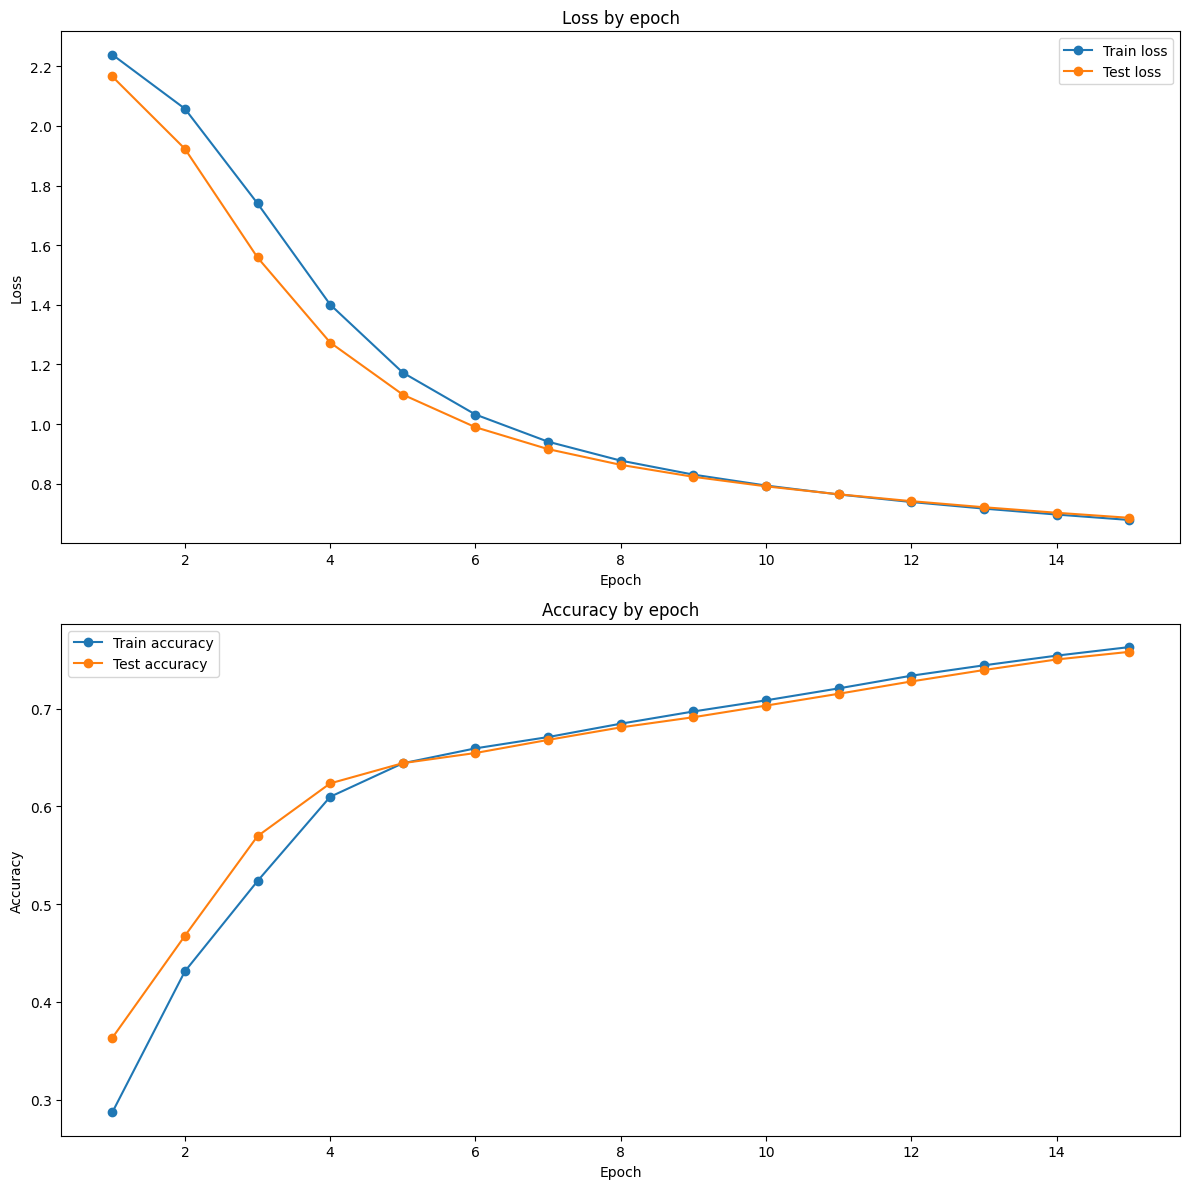

In [69]:
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(2,1, figsize=(12, 12))

axes[0].plot(epochs_range, train_losses, marker="o", label="Train loss")
axes[0].plot(epochs_range, test_losses, marker="o", label="Test loss")
axes[0].set_title("Loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, train_accuracies, marker="o", label="Train accuracy")
axes[1].plot(epochs_range, test_accuracies, marker="o", label="Test accuracy")
axes[1].set_title("Accuracy by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Save, reload, and inspect a prediction

The remaining cells show a standard deployment-oriented pattern: save the learned weights, recreate the model, reload the saved state, and then run one sample image through the network to compare the predicted class with the true label.

This is similar in spirit to saving a Keras model and then loading it for inference. One difference is that PyTorch often saves just the learned parameter dictionary with `state_dict()` rather than saving the full model object by default, so recreating the architecture is part of the reload process.

In [70]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [71]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

Predicted: "Bag", Actual: "Bag"


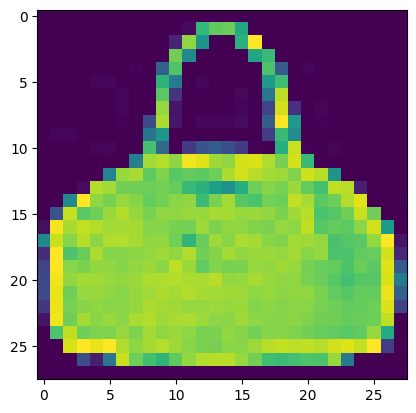

In [72]:
import random

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# put the model in "eval" mode instead of "train" mode
model.eval()

# grab an x,y just like it's a list (easier than tensorflow datasets!)
index = random.randint(0, len(test_data))
x, y = test_data[index][0], test_data[index][1]

# x is a batch of size 1, so x[0] is a 28x28 image
plt.imshow(x[0])

with torch.no_grad(): # no_grad = not doing backprop
    x = x.to(device) ## we have to move x to the GPU
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

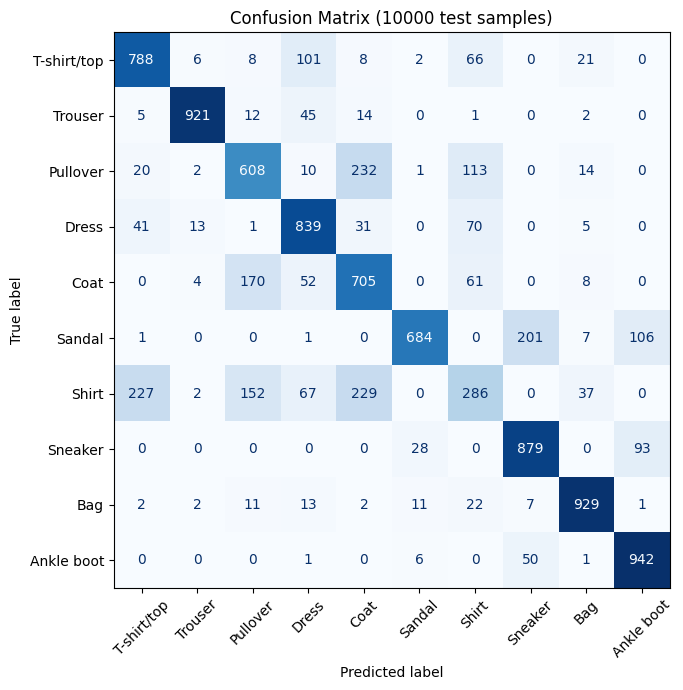

In [ ]:
num_samples = len(test_data)
all_true_labels = []
all_pred_labels = []

model.eval()

with torch.no_grad():
    for images, true_labels in test_dataloader: # for each batch
        images = images.to(device)
        logits = model(images)
        pred_labels = logits.argmax(dim=1)
        # add the results to a running total
        all_true_labels.extend(true_labels.tolist())
        all_pred_labels.extend(pred_labels.cpu().tolist())

cm = confusion_matrix(all_true_labels, all_pred_labels)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix ({num_samples} test samples)")
plt.tight_layout()
plt.show()